# GUS01D: Pre-1999 Voivodeship Overlay Analysis

This notebook overlays current gminas onto pre-1999 voivodeship boundaries (49 voivodeships, 1975-1998).

**Workflow:**
1. Load the GeoTERYT database (v3.0)
2. Load pre-1999 voivodeship boundaries from `voivodeships_1975_49_clean_EPSG2180.geojson`
3. Overlay gminas onto old voivodeships using area-based assignment
4. Update database records with `old_woj` and `old_woj_id` attributes
5. Validate and export results
6. Save complete database with pickle for future use

**Required**: Run `02Alt_borders.ipynb` first to generate the voivodeship GeoJSON file with names

**New v3.0 Features Used:**
- `update_records=True` in overlay to add old_woj/old_woj_id to TERYTRecord
- `save_complete()` to persist database with geometries
- `TERYTRecord.display()` for nice output

In [5]:
# =============================================================================
# STEP 1: Imports and Path Setup
# =============================================================================
import os
import sys
from pathlib import Path
import importlib

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import unary_union

# Find the repository root
def find_repo_root(start=Path.cwd()):
    for p in [start] + list(start.parents):
        if (p / 'Code').exists() or (p / '.git').exists():
            return p
    return start

repo_root = find_repo_root()
tools_path = repo_root / 'Code' / 'tools'
if str(tools_path) not in sys.path:
    sys.path.insert(0, str(tools_path))

# Reload geoTERYT_db to get latest version
import geoTERYT_db as gtdb
importlib.reload(gtdb)

# Data paths
data_root = repo_root.parent.parent / 'Data'
geo_root = data_root / 'Geospatial'
gus_root = data_root / 'GUS'

print(f"Repository root: {repo_root}")
print(f"Data root: {data_root}")
print(f"Geospatial root: {geo_root}")

Repository root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/local_repo/LRDWI-Paper
Data root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data
Geospatial root: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial


## Step 2: Load GeoTERYT Database

In [6]:
# =============================================================================
# STEP 2: Load Complete GeoTERYT Database from GUS01C
# =============================================================================
# Use the reloaded module
LEVEL_GMINA = gtdb.LEVEL_GMINA
LEVEL_VOIVODESHIP = gtdb.LEVEL_VOIVODESHIP

# Load the complete database (built and saved in GUS01C)
complete_db_path = geo_root / 'geoteryt_complete.pkl'
db = gtdb.load_complete_database(complete_db_path)

db.print_summary()

Loading complete database from /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete.pkl...
  Database version: 3.0
  ✓ Loaded 4560 records
  ✓ Year range: 1999 - 2024
  ✓ Records with geometry: 2555
GeoTERYT Database Summary (v3.0)
Total records:           4,560
Year range:              1999 - 2024
------------------------------------------------------------
Administrative levels:
  Voivodeships (2):      16
  Powiats (5):           382
  Gminas (6):            4162
------------------------------------------------------------
Change tracking:
  Records with changes:      773
  Records with level changes: 0
  Records with kind changes:  0
------------------------------------------------------------
Geometry:
  Records with geometry: 2555
  Geometry years:        []
  Poland boundary set:   False


## Step 3: Load Pre-1999 Voivodeship Boundaries

In [7]:
# =============================================================================
# STEP 3: Load Pre-1999 Voivodeship Boundaries
# =============================================================================
# pre1999_path = geo_root / 'voivodeships_1975_final.geojson'
pre1999_path = geo_root / 'voivodeships_1975_49_clean_EPSG2180.geojson'

if not pre1999_path.exists():
    raise FileNotFoundError(f"Pre-1999 boundaries not found: {pre1999_path}\nRun 02_borders.ipynb first!")

pre1999_gdf = gpd.read_file(pre1999_path)
pre1999_gdf = pre1999_gdf.to_crs('EPSG:2180')  # Ensure projected CRS

print(f"Loaded {len(pre1999_gdf)} pre-1999 voivodeships")
print(f"Expected: 49 voivodeships")
print(f"\nVoivodeship areas (sample):")
for idx, row in pre1999_gdf.head(10).iterrows():
    area_km2 = row.geometry.area / 1e6
    print(f"  {row['name']}: {area_km2:,.0f} km²")

# Sanity check: total area should be ~312,685 km²
total_area = pre1999_gdf.geometry.area.sum() / 1e6
print(f"\nTotal area: {total_area:,.0f} km² (Poland ≈ 312,685 km²)")

Loaded 49 pre-1999 voivodeships
Expected: 49 voivodeships

Voivodeship areas (sample):
  bialskopodlaskie: 6,693 km²
  białostockie: 10,069 km²
  bielskie: 3,700 km²
  bydgoskie: 10,344 km²
  chełmskie: 6,787 km²
  ciechanowskie: 4,397 km²
  częstochowskie: 6,176 km²
  elbląskie: 6,110 km²
  gdańskie: 7,388 km²
  gorzowskie: 8,483 km²

Total area: 312,648 km² (Poland ≈ 312,685 km²)


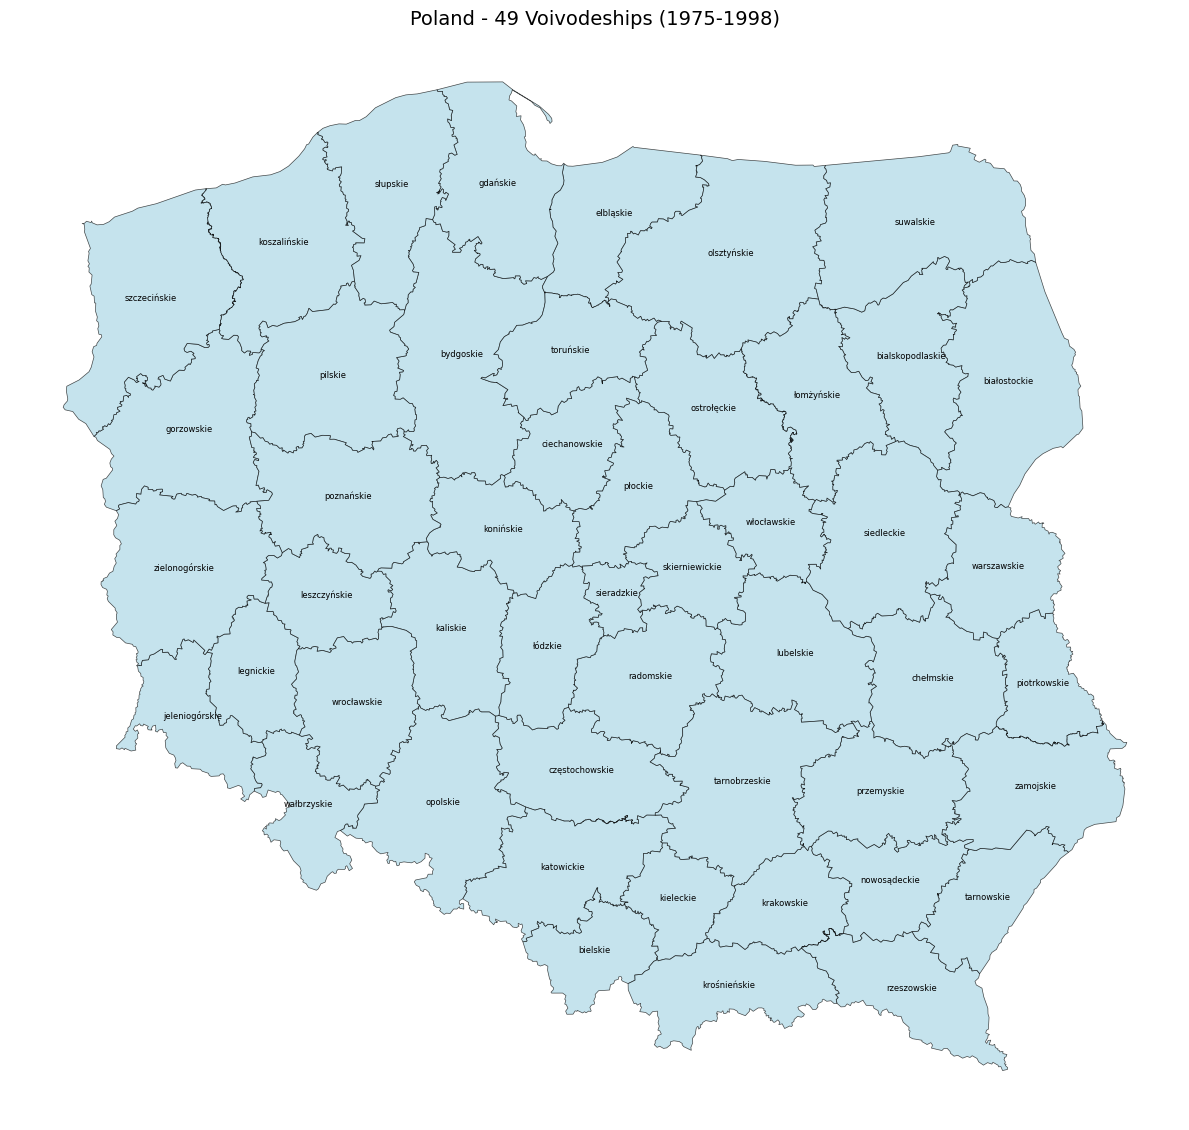

In [8]:
# Visualize pre-1999 voivodeships
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
pre1999_gdf.plot(ax=ax, edgecolor='black', linewidth=0.5, facecolor='lightblue', alpha=0.7)

for idx, row in pre1999_gdf.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['name'], xy=(centroid.x, centroid.y), ha='center', fontsize=6)

ax.set_title('Poland - 49 Voivodeships (1975-1998)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Overlay Gminas onto Pre-1999 Voivodeships

In [9]:
# =============================================================================
# STEP 4: Overlay Gminas onto Pre-1999 Voivodeships
# =============================================================================
# Use 'area' method for most accurate assignment (assigns to voivodeship with max overlap)
# Set update_records=True to add old_woj and old_woj_id attributes to database records
year = 2020

result_gdf = db.assign_gminas_to_pre1999_voivodeships(
    year=year,
    pre1999_boundaries_gdf=pre1999_gdf,
    voivodeship_name_col='name',
    voivodeship_id_col='voiv_id',  # Now available in the GeoJSON
    method='area',  # Use area overlap for accurate assignment
    update_records=True  # Update database records with old_woj, old_woj_id
)

print(f"Overlay complete for year {year}!")
print(f"\nGminas per pre-1999 voivodeship (top 15):")
print(result_gdf['pre1999_voivodeship'].value_counts().head(15))

# Check for unassigned gminas
unassigned_count = result_gdf['pre1999_voivodeship'].isna().sum()
print(f"\nUnassigned gminas: {unassigned_count}")

Assigning 2482 gminas to pre-1999 voivodeships...
  ✓ Assigned 2482 gminas to voivodeships
  ✓ Updated 2482 database records with old_woj/old_woj_id
Overlay complete for year 2020!

Gminas per pre-1999 voivodeship (top 15):
pre1999_voivodeship
katowickie        98
tarnobrzeskie     80
siedleckie        75
chełmskie         69
opolskie          65
lubelskie         63
gdańskie          63
poznańskie        62
krośnieńskie      60
bielskie          59
bydgoskie         59
olsztyńskie       58
kaliskie          58
częstochowskie    58
zamojskie         57
Name: count, dtype: int64

Unassigned gminas: 0


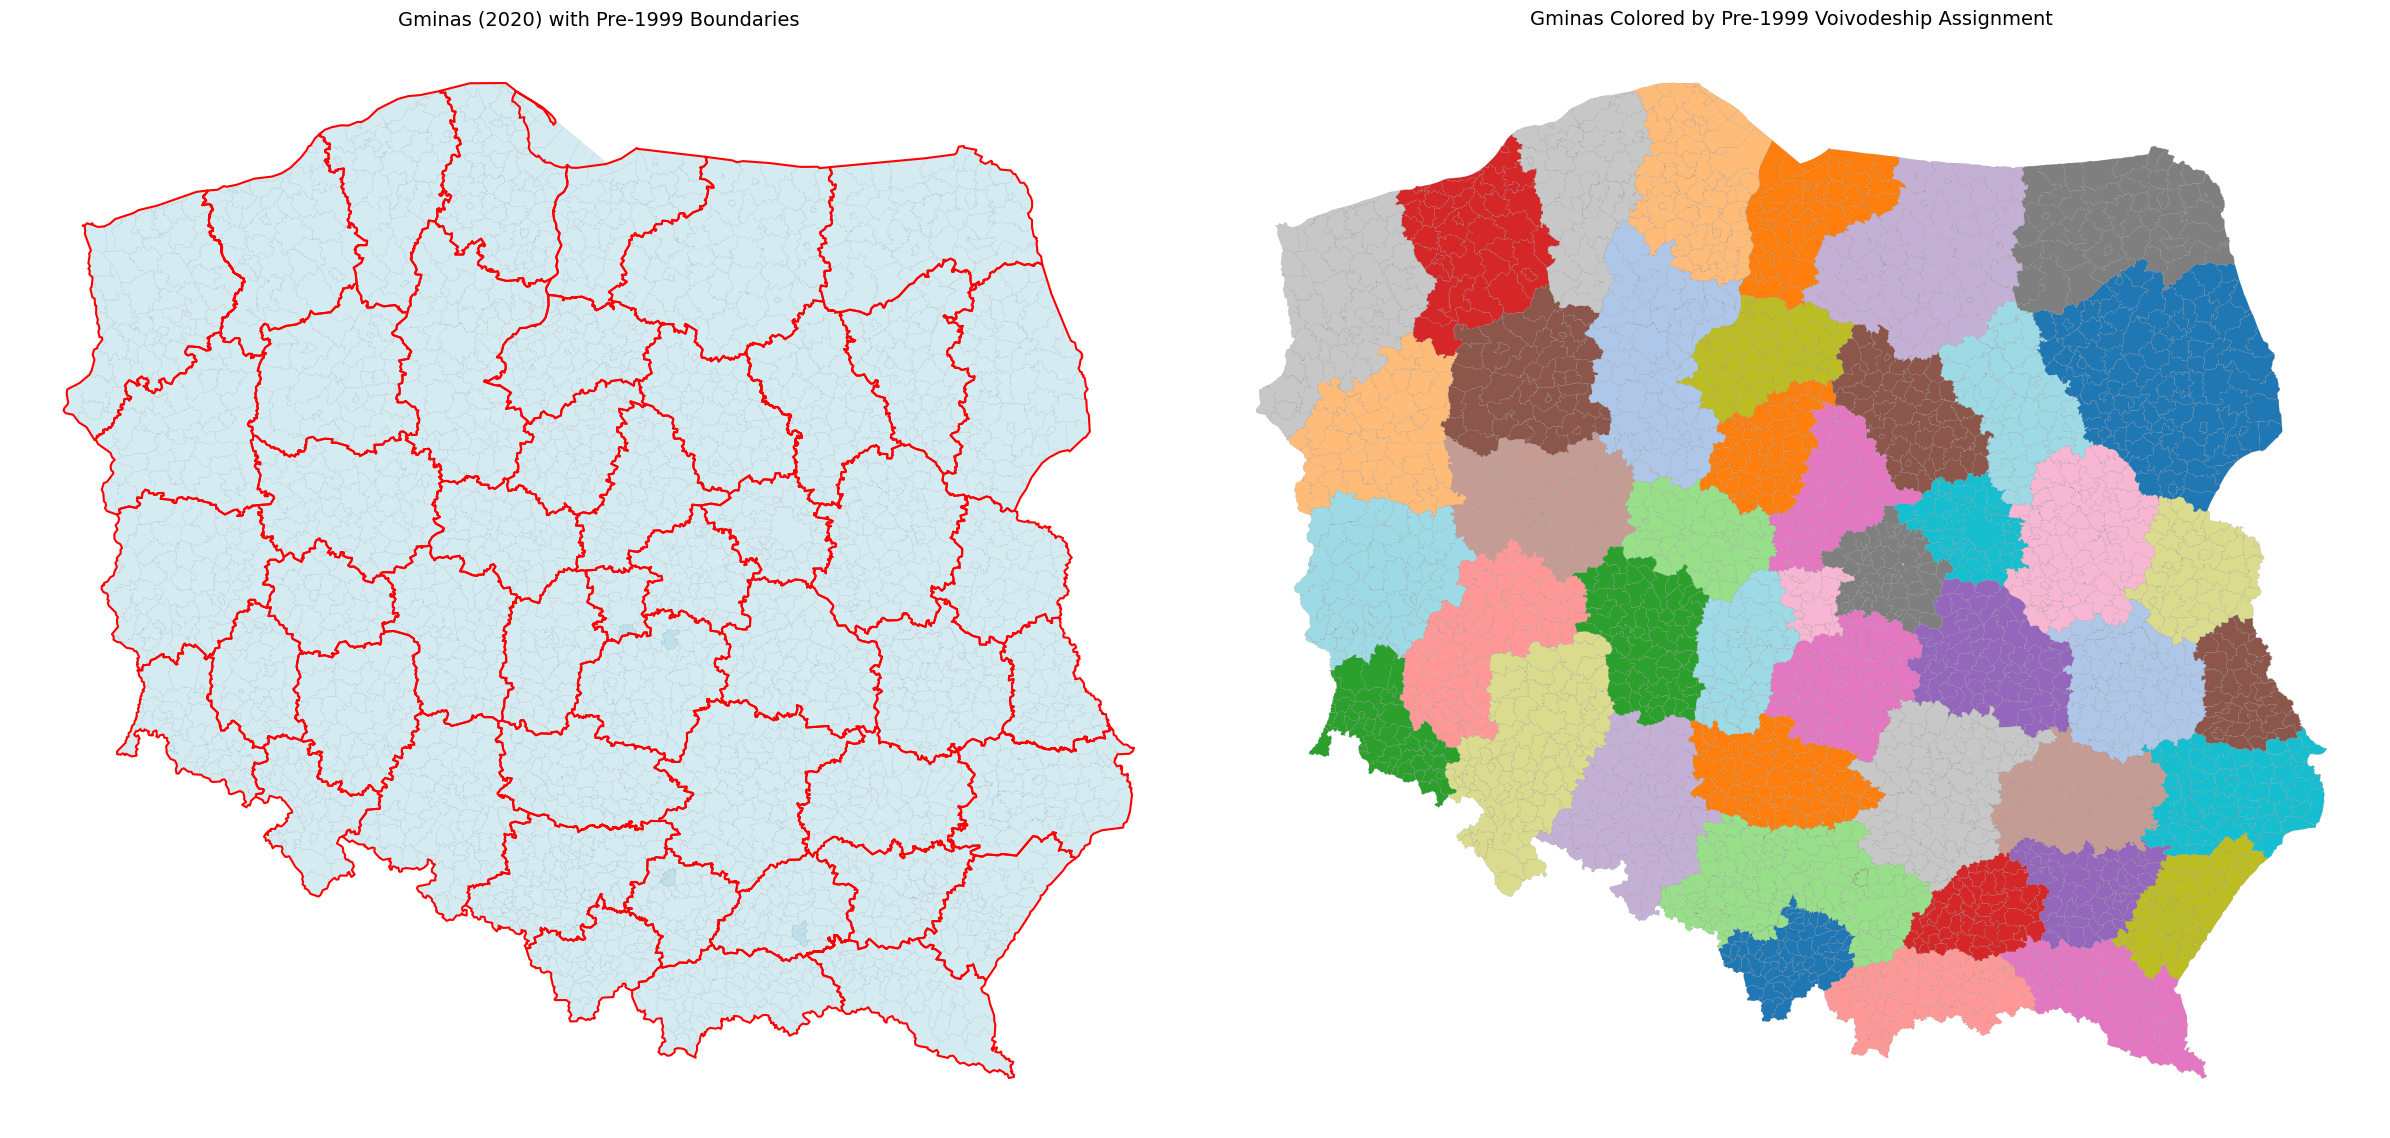

In [10]:
# Visualize overlay results
fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# Left: Pre-1999 boundaries overlaid on gminas
ax1 = axes[0]
result_gdf.plot(ax=ax1, edgecolor='gray', linewidth=0.1, facecolor='lightblue', alpha=0.5)
pre1999_gdf.plot(ax=ax1, edgecolor='red', linewidth=1.5, facecolor='none')
ax1.set_title(f'Gminas ({year}) with Pre-1999 Boundaries', fontsize=14)
ax1.axis('off')

# Right: Gminas colored by assigned voivodeship
ax2 = axes[1]
result_gdf.plot(ax=ax2, column='pre1999_voivodeship', edgecolor='gray', linewidth=0.1, cmap='tab20', legend=False)
ax2.set_title('Gminas Colored by Pre-1999 Voivodeship Assignment', fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

## Step 5: Validate Results

In [11]:
# =============================================================================
# STEP 5: Validate Results
# =============================================================================

# Get current voivodeship names for cross-reference
voiv_records = db.get_divisions_by_level(LEVEL_VOIVODESHIP)
voiv_names = {r.woj: r.name for r in voiv_records}
result_gdf['current_voivodeship'] = result_gdf['woj'].map(voiv_names)

# Cross-tabulation: Current vs Pre-1999 voivodeships
print("Mapping: Current Voivodeships → Pre-1999 Voivodeships")
print("=" * 60)

for current_voiv in sorted(result_gdf['current_voivodeship'].dropna().unique()):
    gminas_in_voiv = result_gdf[result_gdf['current_voivodeship'] == current_voiv]
    old_voivs = gminas_in_voiv['pre1999_voivodeship'].value_counts().head(3)
    print(f"\n{current_voiv} ({len(gminas_in_voiv)} gminas):")
    for old_voiv, count in old_voivs.items():
        pct = 100 * count / len(gminas_in_voiv)
        print(f"  → {old_voiv}: {count} ({pct:.1f}%)")

Mapping: Current Voivodeships → Pre-1999 Voivodeships

DOLNOŚLĄSKIE (169 gminas):
  → wałbrzyskie: 45 (26.6%)
  → wrocławskie: 40 (23.7%)
  → jeleniogórskie: 40 (23.7%)

KUJAWSKO-POMORSKIE (144 gminas):
  → bydgoskie: 54 (37.5%)
  → ciechanowskie: 46 (31.9%)
  → toruńskie: 44 (30.6%)

LUBELSKIE (213 gminas):
  → chełmskie: 69 (32.4%)
  → zamojskie: 57 (26.8%)
  → warszawskie: 34 (16.0%)

LUBUSKIE (82 gminas):
  → zielonogórskie: 53 (64.6%)
  → gorzowskie: 27 (32.9%)
  → leszczyńskie: 2 (2.4%)

MAZOWIECKIE (314 gminas):
  → siedleckie: 63 (20.1%)
  → lubelskie: 61 (19.4%)
  → włocławskie: 47 (15.0%)

MAŁOPOLSKIE (184 gminas):
  → krośnieńskie: 60 (32.6%)
  → krakowskie: 41 (22.3%)
  → kieleckie: 39 (21.2%)

OPOLSKIE (71 gminas):
  → opolskie: 65 (91.5%)
  → częstochowskie: 6 (8.5%)

PODKARPACKIE (160 gminas):
  → nowosądeckie: 47 (29.4%)
  → rzeszowskie: 43 (26.9%)
  → tarnowskie: 41 (25.6%)

PODLASKIE (118 gminas):
  → białostockie: 55 (46.6%)
  → bialskopodlaskie: 41 (34.7%)
  → suwal

In [12]:
# Sanity check: Look for suspicious assignments
# Białostockie should only contain gminas from Podlaskie (woj=20)

suspicious = result_gdf[
    (result_gdf['pre1999_voivodeship'] == 'bialostockie') & 
    (result_gdf['woj'] != '20')
]

print(f"Sanity Check: białostockie assignments outside Podlaskie")
print(f"Suspicious assignments: {len(suspicious)}")

if len(suspicious) > 0:
    print("\nSuspicious gminas (may be boundary edge cases):")
    print(suspicious[['teryt_id', 'name', 'current_voivodeship']].head(10).to_string())
else:
    print("✓ All białostockie assignments are within Podlaskie - data looks correct!")

Sanity Check: białostockie assignments outside Podlaskie
Suspicious assignments: 0
✓ All białostockie assignments are within Podlaskie - data looks correct!


## Step 6: Export Results

In [13]:
# =============================================================================
# STEP 6: Export Results
# =============================================================================

# Export as GeoJSON (with geometry)
output_geojson = geo_root / f'gminas_{year}_with_pre1999_voiv.geojson'
result_gdf.to_file(output_geojson, driver='GeoJSON')
print(f"✓ Exported GeoJSON: {output_geojson}")

# Export as CSV (without geometry, for easy analysis)
output_csv = geo_root / f'gminas_{year}_pre1999_mapping.csv'
result_df = result_gdf.drop(columns='geometry')
result_df.to_csv(output_csv, index=False)
print(f"✓ Exported CSV: {output_csv}")

# Summary
print(f"\n{'='*60}")
print(f"SUMMARY")
print(f"{'='*60}")
print(f"Total gminas: {len(result_gdf):,}")
print(f"Assigned to pre-1999 voivodeships: {result_gdf['pre1999_voivodeship'].notna().sum():,}")
print(f"Unique pre-1999 voivodeships: {result_gdf['pre1999_voivodeship'].nunique()}")
print(f"{'='*60}")

✓ Exported GeoJSON: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gminas_2020_with_pre1999_voiv.geojson
✓ Exported CSV: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/gminas_2020_pre1999_mapping.csv

SUMMARY
Total gminas: 2,482
Assigned to pre-1999 voivodeships: 2,482
Unique pre-1999 voivodeships: 49


## Step 7: Verify old_woj Attributes in Database Records

In [14]:
# =============================================================================
# STEP 7: Verify old_woj Attributes in Database Records
# =============================================================================
# Check that database records now have old_woj and old_woj_id attributes

# Sample a few gminas
sample_gminas = db.get_divisions_by_year(year, level=LEVEL_GMINA)[:10]

print("Sample gminas with old_woj assignments:")
print("-" * 70)
for g in sample_gminas:
    print(f"  {g.teryt_id} {g.name:<25} → old_woj: {g.old_woj}, old_woj_id: {g.old_woj_id}")

# Count gminas with old_woj assigned
all_gminas = db.get_divisions_by_year(year, level=LEVEL_GMINA)
with_old_woj = sum(1 for g in all_gminas if g.old_woj is not None)
print(f"\n✓ {with_old_woj}/{len(all_gminas)} gminas have old_woj assigned")

# Show new display() method
print("\n\nUsing TERYTRecord.display() method:")
sample_gminas[0].display()

Sample gminas with old_woj assignments:
----------------------------------------------------------------------
  1015022 Głuchów                   → old_woj: skierniewickie, old_woj_id: 35
  1818042 Radomyśl nad Sanem        → old_woj: przemyskie, old_woj_id: 29
  0602092 Łukowa                    → old_woj: zamojskie, old_woj_id: 46
  3212033 Lipiany                   → old_woj: szczecińskie, old_woj_id: 37
  3030053 Września                  → old_woj: poznańskie, old_woj_id: 28
  3210022 Boleszkowice              → old_woj: gorzowskie, old_woj_id: 10
  2202043 Czersk                    → old_woj: bydgoskie, old_woj_id: 4
  1421011 Piastów                   → old_woj: włocławskie, old_woj_id: 45
  0264029 Wrocław-Fabryczna         → old_woj: None, old_woj_id: None
  2010011 Siemiatycze               → old_woj: białostockie, old_woj_id: 2

✓ 2482/2514 gminas have old_woj assigned


Using TERYTRecord.display() method:


,Field,Value
0,teryt_id,1015022
1,name,Głuchów
2,name_dod,gmina wiejska
3,level,6
4,kind,rural
5,woj,10
6,pow,15
7,gmi,02
8,rodz,2
9,years_valid,"[np.int64(1999), np.int64(2000), np.int64(2001..."


## Step 8: Save Complete Database with Old Voivodeship Assignments

In [15]:
# =============================================================================
# STEP 8: Save Complete Database with Old Voivodeship Assignments
# =============================================================================
# Save the database with all records updated with old_woj assignments

complete_db_path = geo_root / 'geoteryt_complete_with_old_woj.pkl'
db.save_complete(complete_db_path)

print(f"✓ Complete database saved to: {complete_db_path}")
print(f"\nTo load this database elsewhere:")
print("    from geoTERYT_db import load_complete_database")
print(f"    db = load_complete_database('{complete_db_path.name}')")

Saving complete database to /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_with_old_woj.pkl...
  ✓ Saved 4560 records
  ✓ File size: 84.4 MB
  ✓ Path: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_with_old_woj.pkl
✓ Complete database saved to: /Users/jedrek/Documents/Studium Volkswirschaftslehre/3. Semester/Long-run dynamics of wealth inequalities/Paper/Data/Geospatial/geoteryt_complete_with_old_woj.pkl

To load this database elsewhere:
    from geoTERYT_db import load_complete_database
    db = load_complete_database('geoteryt_complete_with_old_woj.pkl')
